In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)
import scanpy as sc
#sc.settings.verbosity = 1
print(sc.__version__)

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


1.11.4


In [2]:
adata = sc.read_h5ad("/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/04_dataset_merge/tissue_dataset.h5ad")

In [3]:
adata.obs.head()

,n_genes,GSM,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet,group,GSE,batch
GSM8980878_UC68_CELL6_N4,790,GSM8980878,1128.0,0.079787,790,0.700355,True,True,True,0.024741,False,UC,GSE296969,0
GSM8980878_UC68_CELL10_N2,1807,GSM8980878,3051.0,0.077352,1807,0.592265,True,True,True,0.025539,False,UC,GSE296969,0
GSM8980878_UC68_CELL14_N2,3154,GSM8980878,6273.0,0.039694,3154,0.502790,True,True,True,0.011227,False,UC,GSE296969,0
GSM8980878_UC68_CELL20_N5,2054,GSM8980878,3109.0,0.019620,2054,0.660663,True,True,True,0.068769,False,UC,GSE296969,0
GSM8980878_UC68_CELL21_N3,4763,GSM8980878,11899.0,0.027986,4763,0.400286,True,True,True,0.046935,False,UC,GSE296969,0


In [4]:
import omicverse as ov
ov.plot_set(dpi=150)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


In [5]:
# 确保原始计数存在（scVI 需要 raw counts）
adata.layers["counts"] = adata.X.copy()

In [6]:
adata

AnnData object with n_obs × n_vars = 374507 × 8243
    obs: 'n_genes', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'group', 'GSE', 'batch'
    var: 'mt'
    layers: 'counts'

In [7]:
# 1. 高变基因（批次感知）
# --------------------------
# scVI 可以自动选择 HVG，但如果你希望手动控制：
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor='seurat_v3',
    batch_key='GSM'
)
adata = adata[:, adata.var['highly_variable']].copy()
print(f"HVG数: {adata.var['highly_variable'].sum()}")

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
HVG数: 3000


In [8]:
# 2. 直接使用 scVI 去批次
# --------------------------
ov.plot_set(dpi=150)
ov.settings.verbose = 1
ov.settings.cpu_gpu_mixed_init()

model = ov.single.batch_correction(
    adata,
    batch_key='GSM',
    methods='scVI',
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb"
)
adata  # 模型训练完会直接在 adata.obsm 中生成 X_scVI

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0
✅ plot_set complete.

CPU-GPU mixed mode activated
...Begin using scVI to correct batch effect


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 5060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/21 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=21` reached.


AnnData object with n_obs × n_vars = 374507 × 3000
    obs: 'n_genes', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'group', 'GSE', 'batch', '_scvi_batch', '_scvi_labels'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'REFERENCE_MANU'
    obsm: 'X_scVI'
    layers: 'counts'

<Axes: title={'center': 'GSE'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

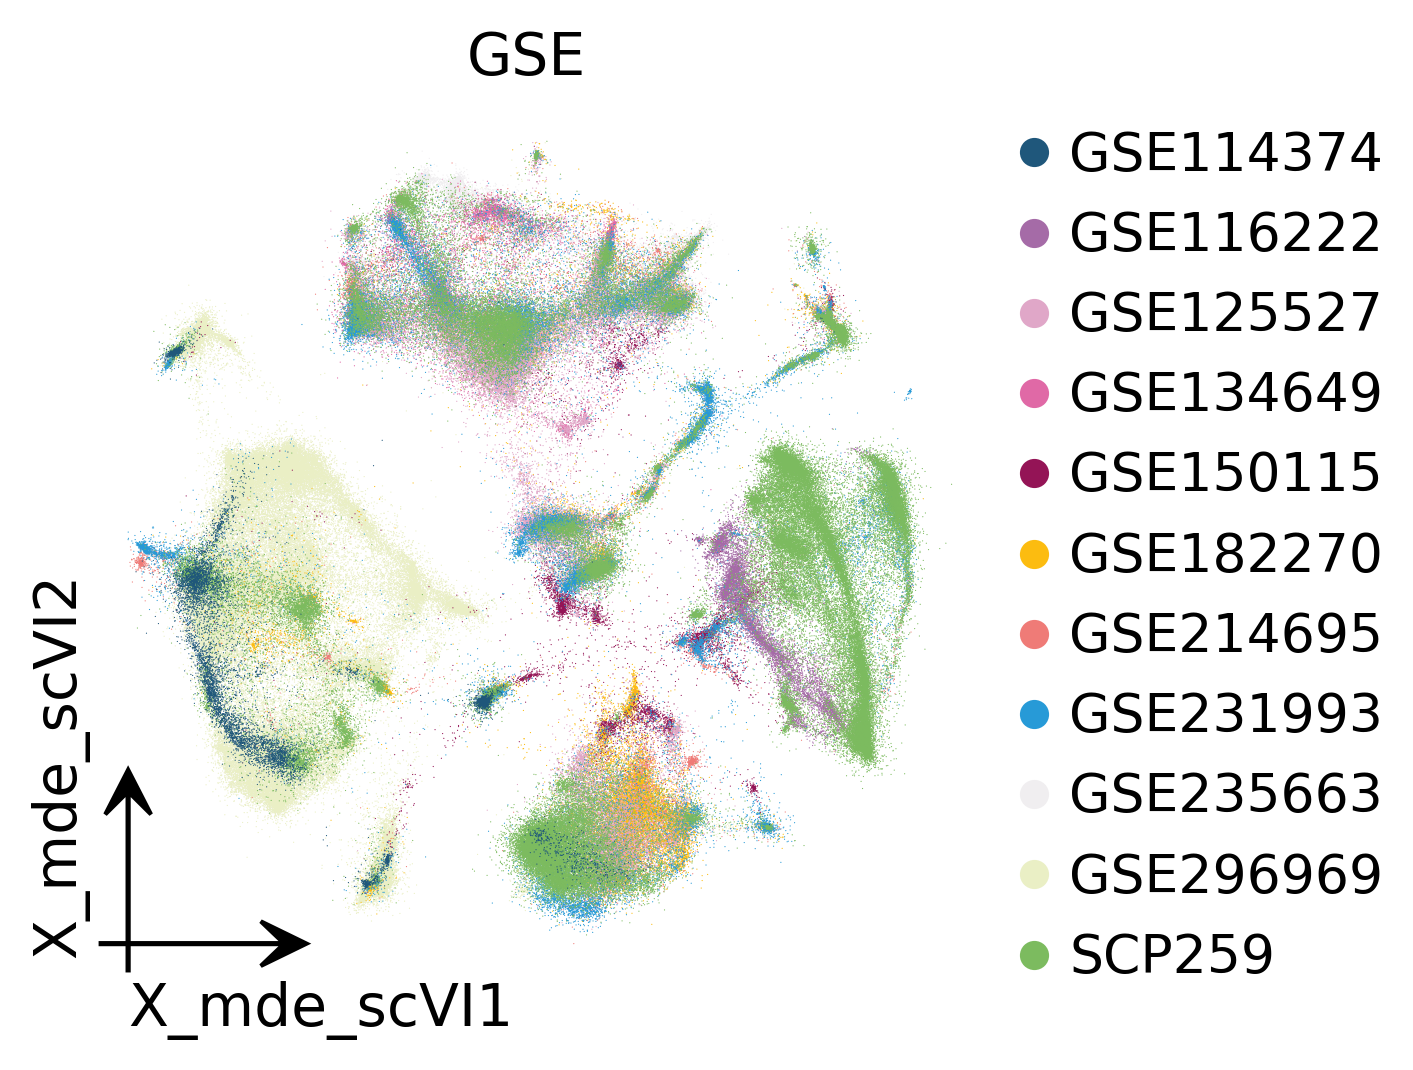

In [10]:
# 3. 聚类与可视化
# --------------------------
adata.obsm["X_mde_scVI"] = ov.utils.mde(adata.obsm["X_scVI"])
ov.utils.embedding(adata, basis='X_mde_scVI', frameon='small', color=['GSE'], show=False)

In [11]:
sc.pp.neighbors(adata, use_rep='X_scVI')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:38)


In [12]:
ov.pp.umap(adata)

🔍 [2025-11-06 11:33:16] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
nvidia-smi not available, using PyTorch CUDA info
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||||------------------------ 3521/16310 MiB (21.6%)
    Allocated: 3521 MiB, Cached: 4556 MiB
computing UMAP🚀
    finished ✅: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:26)
✅ UMAP completed successfully.


In [13]:
ov.pp.leiden(adata,resolution=0.2)

🖥️ Using Scanpy CPU Leiden...
running Leiden clustering
    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:04:37)


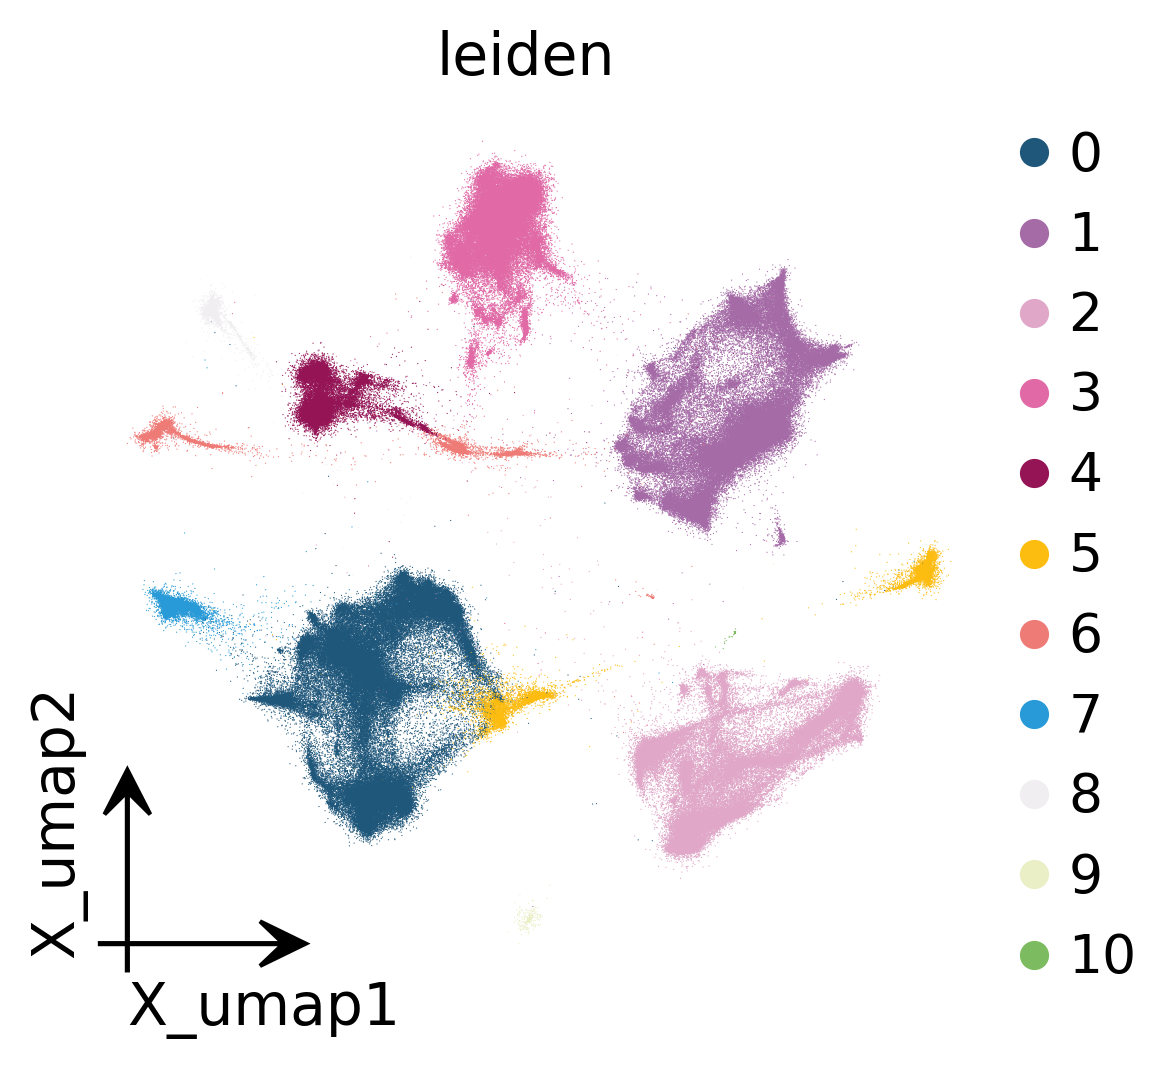

In [14]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden'],
                frameon='small')      

In [15]:
adata

AnnData object with n_obs × n_vars = 374507 × 3000
    obs: 'n_genes', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'group', 'GSE', 'batch', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'REFERENCE_MANU', 'GSM_colors', 'GSE_colors', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_scVI', 'X_mde_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## GPT自动注释

In [27]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:07)


{'0': ['COL6A2',
  'GSN',
  'TIMP2',
  'EGR1',
  'HSPA1A',
  'CD63',
  'CD81',
  'IFITM3',
  'VIM',
  'CFD'],
 '1': ['ARHGDIB',
  'IL32',
  'CORO1A',
  'PTPRC',
  'ACTB',
  'CD52',
  'CD3E',
  'CD2',
  'CD3D',
  'SRGN'],
 '10': ['PRDX1', 'FTL', 'TKT'],
 '2': ['SRI',
  'S100A6',
  'COX5B',
  'SPINT2',
  'COX5A',
  'KRT18',
  'CD9',
  'LGALS3',
  'S100A10',
  'ETHE1'],
 '3': ['CD79A',
  'MZB1',
  'DERL3',
  'SEC11C',
  'SSR4',
  'SPCS1',
  'XBP1',
  'FKBP11',
  'HERPUD1',
  'SPCS2'],
 '4': ['RPL18A',
  'CD79A',
  'LAPTM5',
  'CD37',
  'CXCR4',
  'CD83',
  'CD52',
  'CD79B',
  'LTB',
  'CD74'],
 '5': ['EPB41L2',
  'ZBTB20',
  'GPR155',
  'EGR1',
  'PMEPA1',
  'HSPA1A',
  'QKI',
  'ANK3',
  'ZSWIM6',
  'PRNP'],
 '6': ['AIF1',
  'CST3',
  'TMSB4X',
  'FCER1G',
  'LST1',
  'ACTB',
  'COTL1',
  'TYROBP',
  'VAMP8',
  'CD74'],
 '7': ['ITGB1',
  'EGR1',
  'HSPA1A',
  'MFGE8',
  'COL18A1',
  'ACTA2',
  'TPM1',
  'RGS16',
  'NR4A1',
  'ATF3'],
 '8': ['CRIP2',
  'FKBP1A',
  'CD320',
  'ENG',
  'CD

In [30]:
import os
os.environ['AGI_API_KEY'] = 'sk-b54d8fd2ec144ce78b32602024fba248'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Fibroblast',
 '1': 'T cell',
 '10': 'Epithelial cell',
 '2': 'Epithelial cell',
 '3': 'B cell',
 '4': 'B cell',
 '5': 'Neuron',
 '6': 'Macrophage',
 '7': 'Smooth muscle cell',
 '8': 'Endothelial cell',
 '9': 'Hepatocyte'}

In [31]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

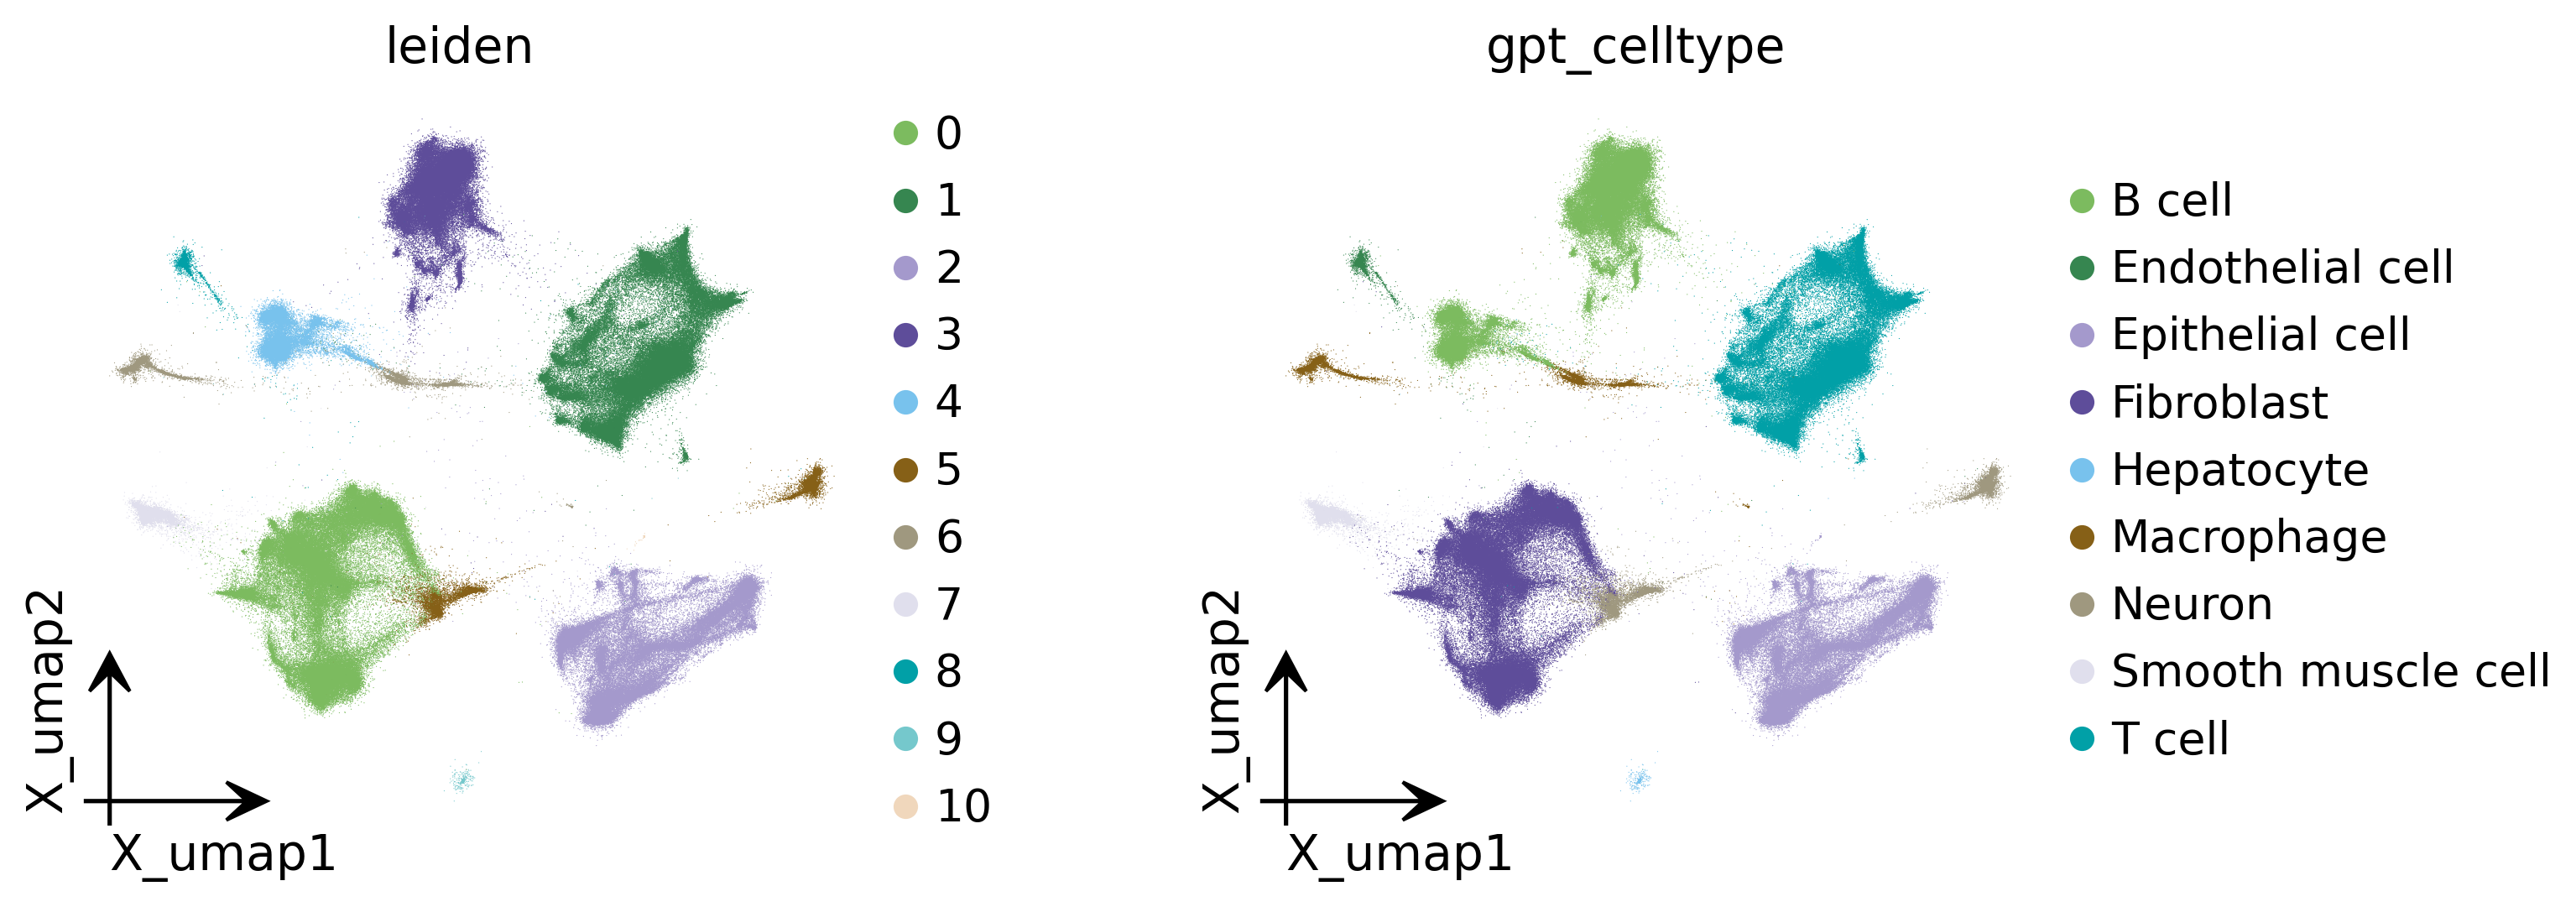

In [32]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

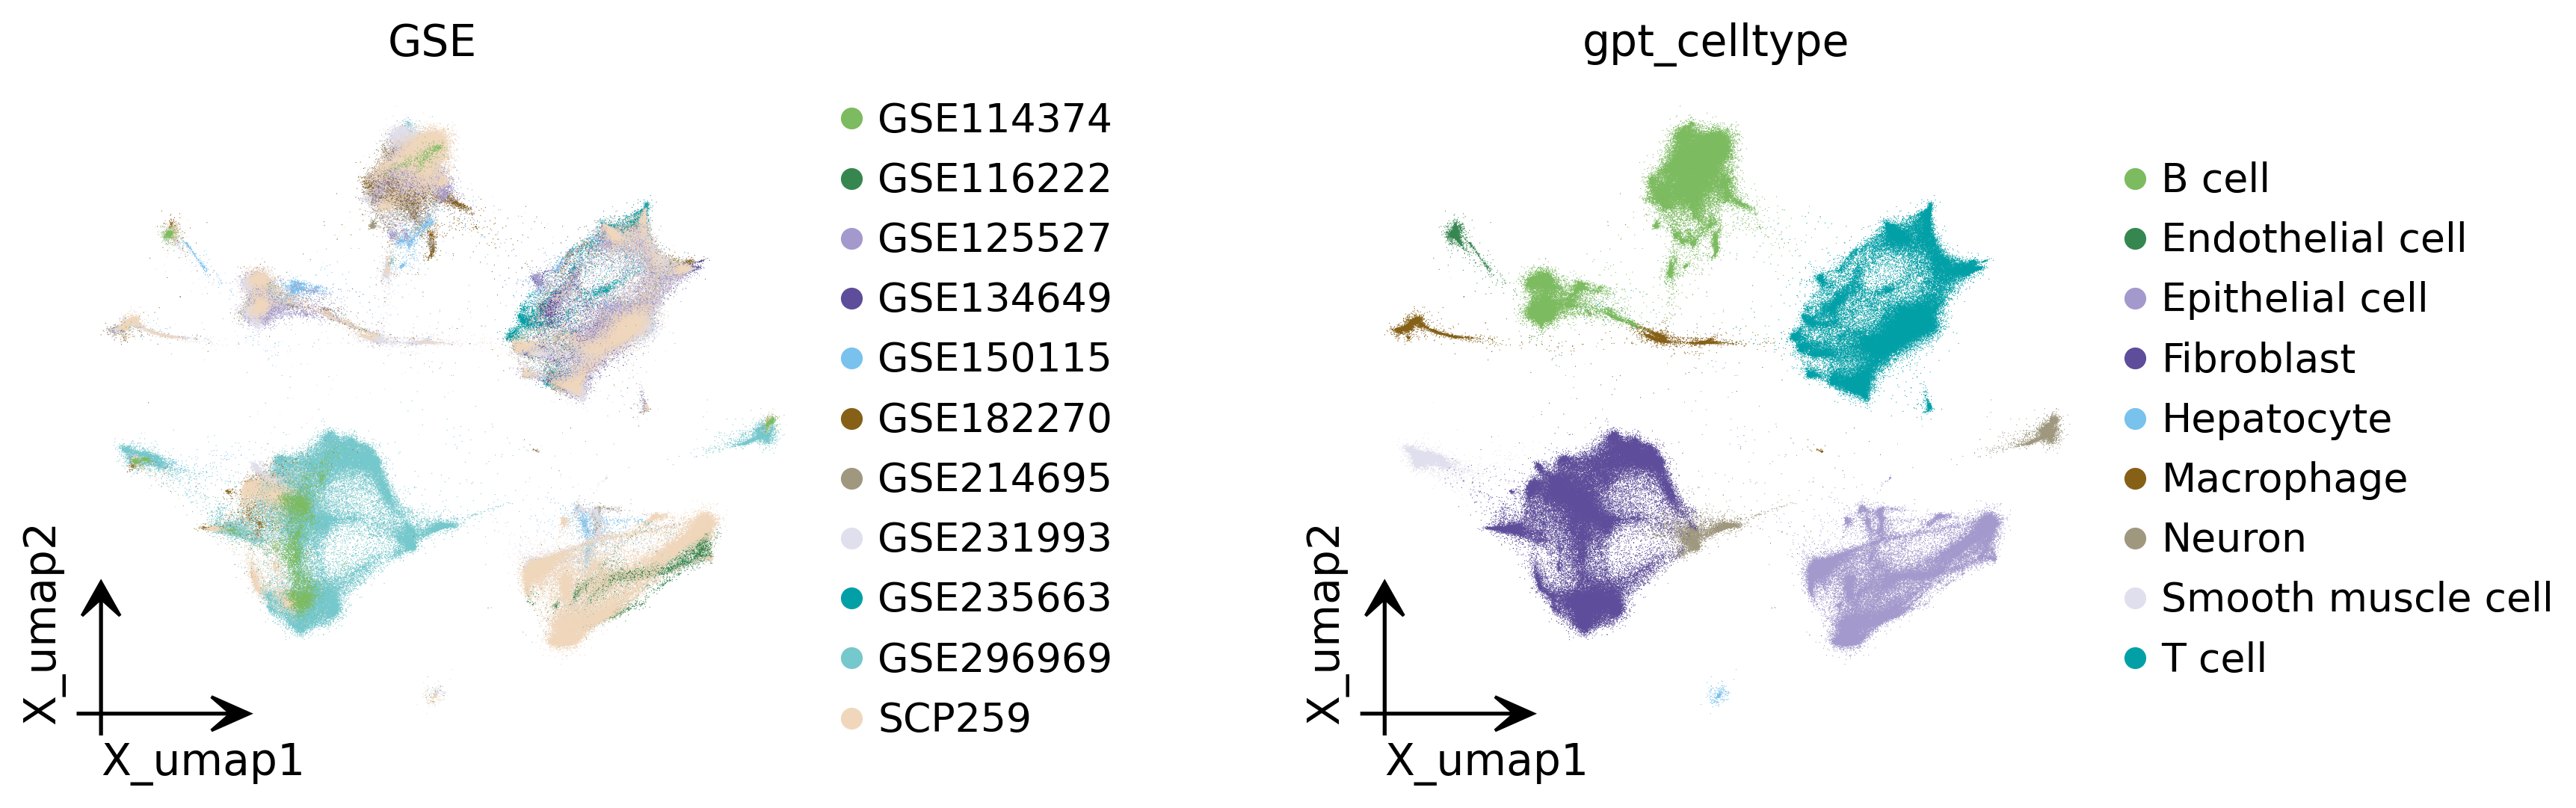

In [35]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['GSE', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.5)

In [33]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Fibroblast            24.648404
T cell                23.757366
B cell                22.439367
Epithelial cell       17.358287
Neuron                 4.094984
Macrophage             3.124374
Smooth muscle cell     2.577522
Endothelial cell       1.319334
Hepatocyte             0.680361
Name: proportion, dtype: float64


In [34]:
save_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/05_scvi_integrated"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "tissue_dataset_scvi.h5ad.gz")

adata.write(save_path, compression='gzip')
print(f"✅ 已使用 gzip 压缩保存: {save_path}")

✅ 已使用 gzip 压缩保存: /mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/05_scvi_integrated/tissue_dataset_scvi.h5ad.gz
